#Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

#Load Dataset

In [ ]:
df = pd.read_csv("/content/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# EDA

In [ ]:
print(df.info())
print("\nTarget distribution (loan_status):")
print(df['loan_status'].value_counts(dropna=False, normalize=True))
print("\nSample stats:")
print(df.describe(include='all').T.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

Target distribution (loan

In [ ]:
# Map Y/N -> 1/0 for cb_person_default_on_file
if 'cb_person_default_on_file' in df.columns:
    df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

# Ensure numeric types
df['loan_status'] = df['loan_status'].astype(int)
df['loan_int_rate'] = pd.to_numeric(df['loan_int_rate'], errors='coerce')

# Fix unrealistic employment length and missing values safely
if 'person_emp_length' in df.columns:
    # Replace impossible values (> 50 years)
    df.loc[df['person_emp_length'] > 50, 'person_emp_length'] = np.nan

    # Fill missing or invalid values with median
    median_emp = df['person_emp_length'].median()
    df['person_emp_length'] = df['person_emp_length'].fillna(median_emp)

    # Finally, convert to integer safely
    df['person_emp_length'] = df['person_emp_length'].astype(int)

# Check missing after conversions
print("Missing per column:\n", df.isnull().sum())


Missing per column:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


#Feature Engineering

In [ ]:
# detect loan & income columns
loan_col = 'loan_amnt' if 'loan_amnt' in df.columns else None
income_col = 'person_income' if 'person_income' in df.columns else None

# loan_to_income
if loan_col and income_col:
    df['loan_to_income'] = df[loan_col] / df[income_col].replace(0, np.nan)
    df['loan_to_income'] = df['loan_to_income'].fillna(df['loan_to_income'].median())
else:
    df['loan_to_income'] = 0.0

# interest decimal
if 'loan_int_rate' in df.columns:
    df['int_rate_decimal'] = df['loan_int_rate'] / 100.0
else:
    df['int_rate_decimal'] = 0.08

# Quick check
df[['loan_to_income','int_rate_decimal']].head()


,loan_to_income,int_rate_decimal
0,0.593220,0.1602
1,0.104167,0.1114
2,0.572917,0.1287
3,0.534351,0.1523
4,0.643382,0.1427


#Train/test split

In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# attempt stratified split, else fallback
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
except Exception as e:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=None)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train target dist:\n", y_train.value_counts(normalize=True))


Train shape: (24435, 13) Test shape: (8146, 13)
Train target dist:
 loan_status
0    0.781829
1    0.218171
Name: proportion, dtype: float64


#Build preprocessors & pipelines

In [ ]:
from sklearn.impute import SimpleImputer

# Identify categorical & numeric columns
categorical_cols = X.select_dtypes(include=['object','category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Remove target-related numeric if present in numeric list (safe)
for rm in ['loan_status']:
    if rm in numeric_cols:
        numeric_cols.remove(rm)

# Numeric transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: one-hot for low-cardinality, ordinal for high-card
low_card = [c for c in categorical_cols if X[c].nunique() <= 8]
high_card = [c for c in categorical_cols if X[c].nunique() > 8]

transformers = [('num', numeric_transformer, numeric_cols)]
if low_card:
    transformers.append(('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card))
if high_card:
    transformers.append(('ord', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                                          ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), high_card))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

# Pipelines
log_pipe = Pipeline(steps=[('pre', preprocessor),
                           ('clf', LogisticRegression(max_iter=1000))])


#Train Logistic Regression

In [ ]:
log_pipe.fit(X_train, y_train)
proba_log_train = log_pipe.predict_proba(X_train)[:,1]
print("Logistic train ROC AUC:", roc_auc_score(y_train, proba_log_train))

Logistic train ROC AUC: 0.8755886585274275


#Train tree model (CatBoost)

In [ ]:
use_catboost = False
try:
    from catboost import CatBoostClassifier
    use_catboost = True
except Exception:
    use_catboost = False

if use_catboost:
    # For CatBoost, we prepare numeric + ordinal categorical
    cat_pre = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat_ord', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                              ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), categorical_cols)
    ])
    tree_pipe = Pipeline(steps=[('pre', cat_pre),
                                ('clf', CatBoostClassifier(verbose=0, random_seed=42))])
else:
    # fallback - use same preprocessor as logistic
    tree_pipe = Pipeline(steps=[('pre', preprocessor),
                                ('clf', GradientBoostingClassifier(random_state=42))])

tree_pipe.fit(X_train, y_train)
proba_tree_train = tree_pipe.predict_proba(X_train)[:,1]
print(("CatBoost" if use_catboost else "GradientBoosting"), "train ROC AUC:", roc_auc_score(y_train, proba_tree_train))


GradientBoosting train ROC AUC: 0.9306058288063842


#Get test probabilities

In [ ]:
proba_log = log_pipe.predict_proba(X_test)[:,1]
proba_tree = tree_pipe.predict_proba(X_test)[:,1]

print("Logistic test ROC AUC:", roc_auc_score(y_test, proba_log))
print("Tree test ROC AUC:", roc_auc_score(y_test, proba_tree))

Logistic test ROC AUC: 0.8783425591371684
Tree test ROC AUC: 0.9287987776329018


#Business cost setup

In [ ]:
# Business parameters (edit to match your business)
LGD = 0.6                 # Loss Given Default for FN
OPPORTUNITY_FACTOR = 0.1  # proportion of interest revenue lost for FP

# Detect loan & rate columns for cost calc
loan_candidates = ['loan_amnt','AMT_CREDIT','AMT_LOAN','loan_amount']
rate_candidates = ['loan_int_rate','int_rate','interest_rate','int_rate_decimal']

loan_col = None
for c in loan_candidates:
    if c in X.columns:
        loan_col = c
        break

rate_col = None
for c in rate_candidates:
    if c in X.columns or c in df.columns:
        rate_col = c
        break

print("Using loan_col =", loan_col, "rate_col =", rate_col)


Using loan_col = loan_amnt rate_col = loan_int_rate


#Compute total cost for a single threshold (explicit loops)

In [ ]:
threshold = 0.5  # example

# choose which probabilities to use (example: logistic)
proba = proba_log  # or proba_tree

# compute predicted labels
preds = (proba >= threshold).astype(int)

# identify FP and FN indices relative to y_test index
y_true_arr = y_test.values
fp_mask = (preds == 1) & (y_true_arr == 0)
fn_mask = (preds == 0) & (y_true_arr == 1)

# loan amounts array
if loan_col:
    loan_amounts = X_test[loan_col].astype(float).values
else:
    # fallback: use median loan_amnt from full df or 10000
    loan_amounts = np.full(len(X_test), df['loan_amnt'].median() if 'loan_amnt' in df.columns else 10000.0)

#


##Show confusion matrix & classification report at 0.5 and at optimal threshold

In [ ]:
import numpy as np

# Define your thresholds (0 to 1)
thresholds = np.linspace(0, 1, 101)

# Business cost parameters
LGD = 0.6
OPPORTUNITY_FACTOR = 0.1

costs_log = []
for t in thresholds:
    preds_temp = (proba_log >= t).astype(int)

    # Identify FP (predicted 1 but actual 0)
    fp_mask = (preds_temp == 1) & (y_test == 0)
    # Identify FN (predicted 0 but actual 1)
    fn_mask = (preds_temp == 0) & (y_test == 1)

    # Calculate costs
    fp_cost = (X_test.loc[fp_mask, 'loan_amnt'] *
               X_test.loc[fp_mask, 'loan_int_rate'] / 100 *
               OPPORTUNITY_FACTOR).sum()

    fn_cost = (X_test.loc[fn_mask, 'loan_amnt'] * LGD).sum()

    total_cost = fp_cost + fn_cost
    costs_log.append(total_cost)

costs_log = np.array(costs_log)

# Find the best threshold
best_idx_log = np.argmin(costs_log)
best_threshold_log = thresholds[best_idx_log]
best_cost_log = costs_log[best_idx_log]

print("✅ Best threshold (Logistic):", best_threshold_log)
print("💰 Minimum total business cost:", best_cost_log)


✅ Best threshold (Logistic): 0.02
💰 Minimum total business cost: 528880.9845


#Plot cost vs threshold

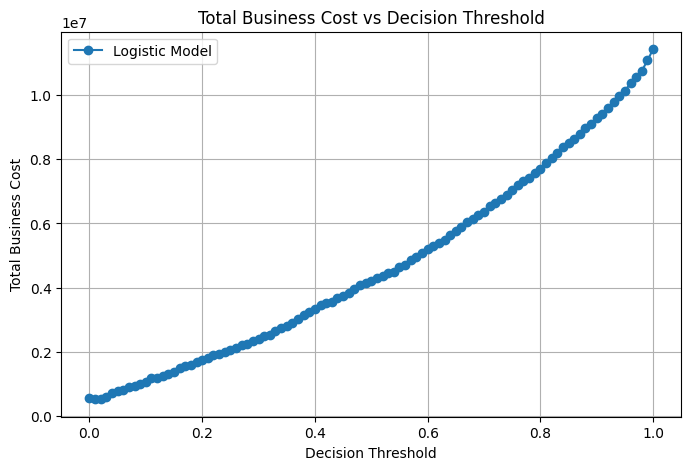

In [ ]:
import matplotlib.pyplot as plt

# (Optional) ensure we have arrays
thresholds = np.array(thresholds)
costs_log = np.array(costs_log)

plt.figure(figsize=(8,5))
plt.plot(thresholds, costs_log, marker='o', label='Logistic Model')
plt.title('Total Business Cost vs Decision Threshold')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Business Cost')
plt.grid(True)
plt.legend()
plt.show()
